# Retrievers in LangChain – Detailed Explanation (One-Time Read)

Retrievers are one of the **most important components** in LangChain, especially when you are building **RAG-based applications**.  
To avoid confusion later, this note explains **everything in detail at once**, so you don’t need to revisit it again.

---

## What Is a Retriever?

A **Retriever** is a LangChain component that:

- Takes a **user query** as input  
- Searches a **data source**  
- Returns the **most relevant documents** as output  

Formally:

> A retriever is a component in LangChain that fetches relevant documents from a data source in response to a user query.

### Key Characteristics
- Input → **User query (string)**
- Output → **List of LangChain `Document` objects**
- Internally performs **search, filtering, and ranking**

You can think of a retriever as:
> A smart search engine sitting between your user and your data.

---

## Why Retrievers Are Important

In LLM applications:
- LLMs **do not know your private data**
- Retrievers bring **relevant context**
- LLMs generate better answers using retrieved documents

Without a retriever:
- Answers are hallucination-prone
- Context is missing
- RAG pipelines break

---

## Core Idea: How Retrievers Work

1. User asks a question
2. Retriever receives the query
3. Retriever searches a data source
4. Relevant documents are fetched
5. Documents are passed to the LLM

---

## Two Ways to Classify Retrievers

Retrievers in LangChain can be classified in **two orthogonal ways**:

1. **Based on Data Source**
2. **Based on Search Strategy**

This classification fully explains **why multiple retrievers exist**.

---

# 1. Retrievers Based on Data Source

These retrievers differ by **where they search**.

---

## 1.1 Wikipedia Retriever

### What It Is
- A retriever that searches **Wikipedia**
- Uses the **Wikipedia API**
- Performs **keyword-based search**

### How It Works
1. User query → `"Albert Einstein"`
2. Query is sent to Wikipedia API
3. Relevant Wikipedia pages are fetched
4. Results are returned as `Document` objects

### Important Notes
- Not semantic search
- No embeddings involved
- Relies on keyword matching
- Accuracy depends on Wikipedia relevance

### When to Use
- General knowledge questions
- Educational assistants
- Quick factual lookup
- Non-private data

### When NOT to Use
- Private data
- Domain-specific corpora
- Semantic similarity requirements

---

## 1.2 Vector Store–Based Retrievers

### What It Is
- Works on **vector databases**
- Uses embeddings
- Performs **semantic similarity search**

### Data Sources
- Chroma
- FAISS
- Pinecone
- Weaviate
- Qdrant

---

### How It Works
1. Documents are converted into embeddings
2. Embeddings are stored in a vector store
3. User query is embedded
4. Similarity search is performed
5. Top-k relevant documents are returned

### Key Strength
- Understands **semantic meaning**
- Handles paraphrasing well
- Ideal for RAG pipelines

### When to Use
- RAG applications
- Internal document search
- Knowledge bases
- Chatbots with custom data

---

## 1.3 Arxiv Retriever

### What It Is
- Searches **research papers**
- Uses Arxiv as the data source

### How It Works
1. User query → `"Transformer architecture"`
2. Retriever queries Arxiv
3. Relevant papers are fetched
4. Abstracts and metadata are returned

### When to Use
- Research assistants
- Academic exploration
- Technical literature search

---

## Key Insight (Data Source Based)

> Different retrievers exist because **data lives in different places**.

---

# 2. Retrievers Based on Search Strategy

Even if the **data source is the same**, different strategies can be used to retrieve documents.

---

## 2.1 Similarity Search Retriever

### Strategy
- Basic embedding similarity
- Uses cosine similarity or distance metrics

### Pros
- Fast
- Simple
- Effective for most use cases

### Cons
- Can return very similar documents
- May lack diversity

---

## 2.2 MMR Retriever (Maximum Marginal Relevance)

### Strategy
- Balances:
  - Relevance
  - Diversity

### Why It Exists
- Avoids repetitive documents
- Prevents redundant context

### Example
Instead of returning:
- Doc A (very similar)
- Doc A’ (almost same)
- Doc A’’ (duplicate)

MMR returns:
- Doc A
- Doc B
- Doc C (diverse but relevant)

### When to Use
- Long contexts
- Multi-topic answers
- Reducing redundancy

---

## 2.3 Multi-Query Retriever

### Strategy
- Uses an LLM to generate **multiple query variants**
- Searches for each query
- Merges results

### Why It Exists
- One query may not capture full intent
- Different phrasing retrieves different documents

### Example
Original query:
> "How does RAG work?"

Generated queries:
- "Explain retrieval augmented generation"
- "How do retrievers help LLMs?"
- "RAG pipeline explanation"

### When to Use
- Ambiguous questions
- Complex information needs
- Knowledge-heavy applications

---

## 2.4 Contextual Compression Retriever

### Strategy
- Retrieve documents
- Then **compress or filter content**
- Keep only relevant parts

### Why It Exists
- LLM context window is limited
- Raw documents may be too large

### When to Use
- Large documents
- PDFs and reports
- Token-sensitive pipelines

---

## Key Insight (Search Strategy Based)

> Different retrievers exist because **searching itself can be done in multiple intelligent ways**.

---

# Very Important Concept: Retrievers Are Runnables

All retrievers in LangChain are:

- **Runnable**
- Chainable
- Pluggable into pipelines

This means:
- You can combine retrievers
- You can insert them into chains
- You can replace them without rewriting logic

---

## Why LangChain Designed Retrievers This Way

LangChain’s philosophy:
- Common interface
- Interchangeable components
- Easy experimentation
- Production scalability

Example:
- Start with FAISS
- Move to Pinecone later
- Minimal code changes

---

## Final Summary (One Screen Memory)

- Retrievers fetch **relevant documents**
- They sit between **user queries and data**
- They are classified by:
  1. **Data source**
  2. **Search strategy**
- Vector-store retrievers power RAG
- Strategy-based retrievers improve quality
- Retrievers are runnable and composable

---

## Mental Model

> **Retriever = Smart Search Engine for LLMs**

If you understand this, you understand retrievers completely.


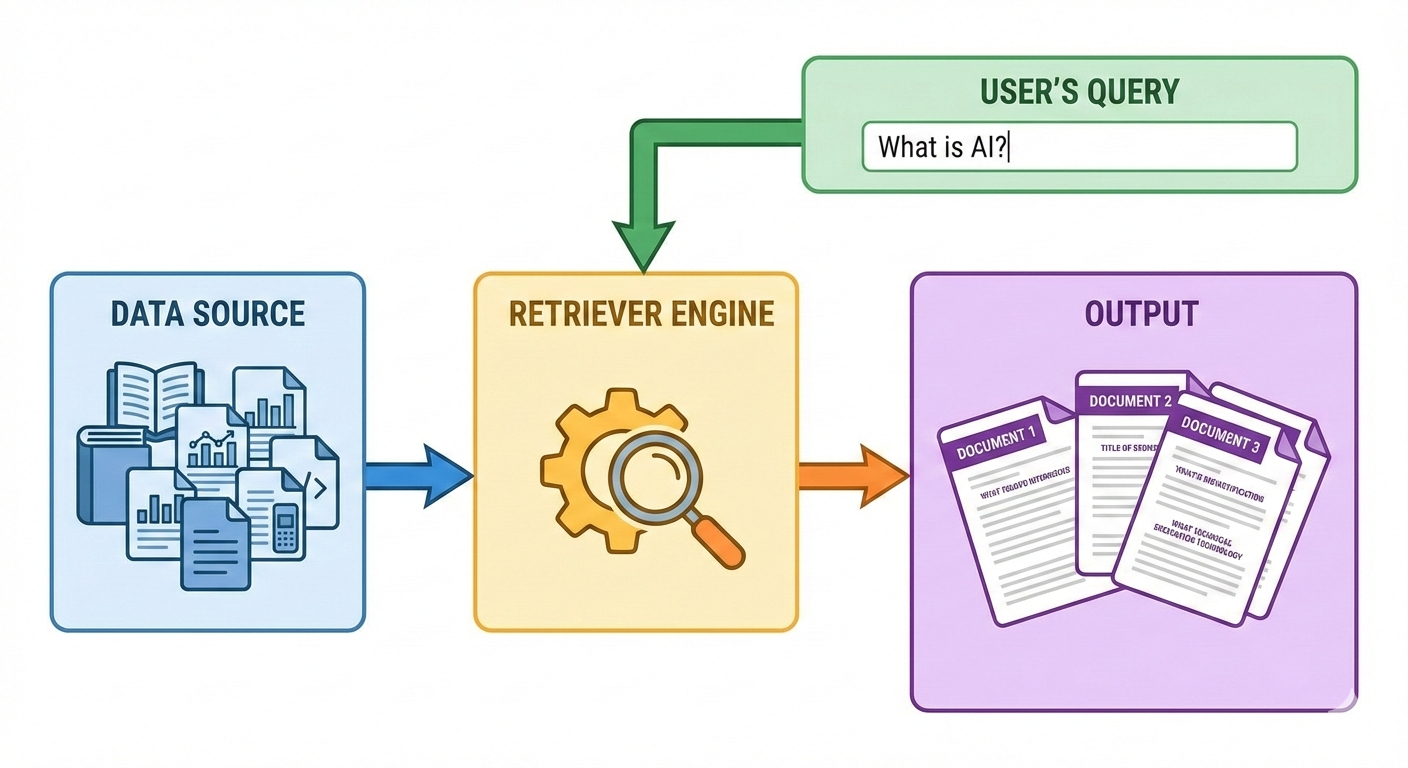

# Wikipedia Retriever

In [1]:
from langchain_community.retrievers import WikipediaRetriever

In [4]:
# Initialize the retriever (optional: set language and top_k)
retriever = WikipediaRetriever(top_k_results=2, lang="en")

In [5]:
# Define your query
query = "the geopolitical history of india and pakistan from the perspective of a chinese"

# Get relevant Wikipedia documents
docs = retriever.invoke(query)

In [6]:
docs

[Document(metadata={'title': 'India–Pakistan war of 1971', 'summary': "The India–Pakistan war of 1971, also known as the third Indo-Pakistani war, was a military confrontation between India and Pakistan that occurred during the Bangladesh Liberation War in East Pakistan from 3 December 1971 until the Pakistani capitulation in Dhaka on 16 December 1971.  The war began with Pakistan's Operation Chengiz Khan, consisting of preemptive aerial strikes on eight Indian air stations. The strikes led to India declaring war on Pakistan, marking their entry into the war for East Pakistan's independence, on the side of Bengali nationalist forces. India's entry expanded the existing conflict with Indian and Pakistani forces engaging on both the eastern and western fronts.\nThirteen days after the war started, India achieved a clear upper hand, and the Eastern Command of the Pakistan military signed the instrument of surrender on 16 December 1971 in Dhaka, marking the formation of East Pakistan as th

In [7]:
# Print retrieved content
for i, doc in enumerate(docs):
    print(f"\n--- Result {i+1} ---")
    print(f"Content:\n{doc.page_content}...")  # truncate for display


--- Result 1 ---
Content:
The India–Pakistan war of 1971, also known as the third Indo-Pakistani war, was a military confrontation between India and Pakistan that occurred during the Bangladesh Liberation War in East Pakistan from 3 December 1971 until the Pakistani capitulation in Dhaka on 16 December 1971.  The war began with Pakistan's Operation Chengiz Khan, consisting of preemptive aerial strikes on eight Indian air stations. The strikes led to India declaring war on Pakistan, marking their entry into the war for East Pakistan's independence, on the side of Bengali nationalist forces. India's entry expanded the existing conflict with Indian and Pakistani forces engaging on both the eastern and western fronts.
Thirteen days after the war started, India achieved a clear upper hand, and the Eastern Command of the Pakistan military signed the instrument of surrender on 16 December 1971 in Dhaka, marking the formation of East Pakistan as the new nation of Bangladesh. Approximately 93,

# Vector Store Retriever in LangChain – Complete & Practical Explanation

A **Vector Store Retriever** is the **most important and most commonly used retriever** in LangChain, especially in **RAG (Retrieval-Augmented Generation)** systems.

If you understand this retriever properly, you understand **how real-world LLM applications work**.

---

## What Is a Vector Store Retriever?

A **Vector Store Retriever** is a retriever that:

- Works on a **vector store (vector database)**
- Uses **embeddings**
- Performs **semantic similarity search**
- Returns the most relevant documents for a user query

In simple words:

> It retrieves documents whose **meaning** is closest to the user query, not just keyword matches.

---

## Why Vector Store Retriever Exists

Keyword search fails when:
- Queries are paraphrased
- Synonyms are used
- Meaning matters more than exact words

Vector store retrievers solve this by:
- Converting text into vectors
- Comparing vectors in high-dimensional space

---

## Core Components Involved

A vector store retriever depends on **three things**:

1. **Embedding Model**
2. **Vector Store**
3. **Similarity Search Strategy**

---

## Step-by-Step: How Vector Store Retriever Works

### Step 1: Document Preparation
- Large documents are split into chunks
- Chunk size is chosen carefully (e.g., 500–1000 tokens)

---

### Step 2: Generate Embeddings
- Each text chunk is converted into a vector
- Example models:
  - OpenAI Embeddings
  - HuggingFace Embeddings

---

### Step 3: Store in Vector Store
- Vectors are stored along with:
  - Original text
  - Metadata (source, page number, etc.)

---

### Step 4: User Query Processing
- User submits a query
- Query is converted into an embedding using **the same embedding model**

---

### Step 5: Similarity Search
- Query vector is compared with stored vectors
- Similarity metrics:
  - Cosine similarity
  - Dot product
  - Euclidean distance

---

### Step 6: Document Retrieval
- Top-k most similar documents are retrieved
- Returned as LangChain `Document` objects

---

## What Does the Retriever Return?

The output is:

- A **list of `Document` objects**
- Each document contains:
  - `page_content`
  - `metadata`

These documents are later passed to the LLM.

---

## Vector Store vs Vector Store Retriever

| Component | Responsibility |
|--------|----------------|
| Vector Store | Stores vectors, indexing, similarity search |
| Vector Store Retriever | Uses vector store to fetch relevant documents |

Retriever is a **thin intelligent layer** over the vector store.

---

## Common Vector Stores Used

- FAISS (local, fast, lightweight)
- Chroma (local + small production)
- Pinecone (managed, scalable)
- Weaviate
- Qdrant

All of them work with **the same retriever interface** in LangChain.

---

## How LangChain Implements Vector Store Retriever

LangChain provides a **common interface**:

```python
retriever = vectorstore.as_retriever()
```

## Behind the Scenes (LangChain Vector Store Retriever)

- **Same method names**  
  All vector stores expose the same retriever-related methods.

- **Same output format**  
  Retrieved results are always returned as LangChain `Document` objects.

- **Different backend implementations**  
  Internally, FAISS, Chroma, Pinecone, Qdrant, etc. work differently, but LangChain hides this complexity.

👉 **Result:** You can easily swap one vector database with another without changing most of your code.

---

## Important Retriever Parameters

### 1. `k`
- Number of documents to retrieve
- Default value is usually **4**
- Controls how much context is sent to the LLM

---

### 2. `search_type`
Defines the retrieval strategy:

- `"similarity"`  
  - Basic semantic similarity search  
  - Retrieves documents closest to the query vector

- `"mmr"`  
  - Maximum Marginal Relevance  
  - Focuses on both relevance **and diversity**

---

### 3. `search_kwargs`
Used for fine-grained control over retrieval behavior:

- `k`  
  Number of final documents returned

- `fetch_k`  
  Number of candidate documents fetched before filtering (important for MMR)

- `lambda_mult`  
  Controls relevance vs diversity trade-off in MMR  
  - Higher → more relevance  
  - Lower → more diversity

---

## Example Retrieval Strategies

### 1. Similarity Search
- Retrieves the most semantically similar documents
- Fast and simple
- May return redundant chunks

---

### 2. MMR (Maximum Marginal Relevance)
- Balances relevance and diversity
- Avoids repeating similar chunks
- Very useful for long or overlapping documents

---

## When to Use Vector Store Retriever

✔ RAG (Retrieval-Augmented Generation) applications  
✔ Chatbots with private or internal data  
✔ PDF / document-based Q&A systems  
✔ Knowledge base search  
✔ Semantic search applications  

---

## When **NOT** to Use It

✘ Very small datasets  
✘ Pure keyword-based search use cases  
✘ Real-time data that cannot be indexed  

---

## Strengths

- Strong semantic understanding
- Works well with paraphrased queries
- Scales efficiently for large datasets
- Backend-agnostic (easy to switch vector databases)

---

## Limitations

- Requires embedding generation (cost + time)
- Performance depends on embedding quality
- Needs a good chunking strategy for best results

---

## Best Practices

- Always use the **same embedding model** for documents and queries
- Tune chunk size and overlap carefully
- Prefer **MMR** for long documents
- Add meaningful metadata for filtering
- Avoid overly large chunks

---

## Mental Model

**Vector Store Retriever = Semantic Search Engine for LLMs**

---

## One-Line Summary

A vector store retriever fetches documents using **semantic similarity via embeddings**, making it the core component of **RAG systems in LangChain**.


# Vector Store Retriever

In [8]:
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document

In [9]:
# Step 1: Your source documents
documents = [
    Document(page_content="LangChain helps developers build LLM applications easily."),
    Document(page_content="Chroma is a vector database optimized for LLM-based search."),
    Document(page_content="Embeddings convert text into high-dimensional vectors."),
    Document(page_content="OpenAI provides powerful embedding models."),
]

In [11]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)
api_key = os.getenv('OPENAI_API_KEY')

In [12]:
# Step 2: Initialize embedding model
embedding_model = OpenAIEmbeddings(api_key=api_key)

# Step 3: Create Chroma vector store in memory
vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embedding_model,
    collection_name="my_collection"
)

In [13]:

# Step 4: Convert vectorstore into a retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

In [14]:
query = "What is Chroma used for?"
results = retriever.invoke(query)

In [15]:

for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
Chroma is a vector database optimized for LLM-based search.

--- Result 2 ---
LangChain helps developers build LLM applications easily.


In [16]:
results = vectorstore.similarity_search(query, k=2)

In [17]:
for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
Chroma is a vector database optimized for LLM-based search.

--- Result 2 ---
LangChain helps developers build LLM applications easily.


## MMR Retriever (Maximum Marginal Relevance)

MMR (Maximum Marginal Relevance) is a **retrieval strategy** used in LangChain to fetch documents that are **highly relevant to a query while avoiding redundant or repetitive content**.

Unlike basic similarity search, which may return multiple documents saying the same thing, MMR ensures **diversity in the retrieved results**.

---

## The Problem with Normal Similarity Search

Assume a document source contains the following documents:

- **D1:** Climate change is causing glaciers to melt rapidly in the Arctic.
- **D2:** Glaciers in the Arctic are melting at an alarming rate due to rising temperatures.
- **D3:** Climate change leads to deforestation affecting biodiversity.
- **D4:** Climate change increases the frequency of wildfires.
- **D5:** Rising sea levels threaten coastal cities.

Now consider the user query:

> **"What are the adverse effects of climate change?"**

### Output from Normal Similarity Search

A standard similarity-based retriever may return:

1. D1 (Glacier melting)
2. D2 (Glacier melting – repeated idea)
3. D3 (Deforestation)

### Why This Is a Problem

- D1 and D2 convey **nearly identical information**
- The user receives **limited perspectives**
- Important impacts like wildfires and sea-level rise are missed

---

## What We Actually Want

An ideal retrieval would look like this:

1. D1 → Glacier melting  
2. D4 → Wildfires  
3. D5 → Coastal flooding  

Here:
- All documents are **relevant**
- Each document adds a **new perspective**

This is exactly what **MMR** is designed to do.

---

## Core Idea of MMR

> **Retrieve documents that are not only relevant to the query but also different from each other.**

MMR balances two competing goals:
- **Relevance** to the query
- **Diversity** among retrieved documents

---

## Formal Definition

**Maximum Marginal Relevance (MMR)** is an information retrieval algorithm designed to **reduce redundancy in retrieved documents while maintaining high relevance to the user’s query**.

---

## How MMR Works (Step-by-Step)

1. Select the **most relevant document** for the query.
2. For the next selection:
   - Choose a document that is relevant to the query  
   - Ensure it is **maximally dissimilar** from already selected documents
3. Repeat until the desired number of documents (`k`) is selected

The result is a **diverse yet relevant set of documents**.

---

## MMR vs Similarity Search

| Aspect | Similarity Search | MMR |
|------|------------------|-----|
| Focus | Relevance only | Relevance + Diversity |
| Redundancy | High | Low |
| Perspective coverage | Narrow | Broad |
| Best for | Short or clean data | Long or overlapping data |

---

## Important MMR Parameters in LangChain

### `k`
- Number of final documents returned

### `fetch_k`
- Number of candidate documents initially fetched before applying MMR  
- Usually greater than `k`

### `lambda_mult`
- Controls the trade-off between relevance and diversity  
- Range: `0 → 1`
  - `1.0` → More relevance
  - `0.0` → More diversity

---

## When to Use MMR

✔ RAG (Retrieval-Augmented Generation) systems  
✔ PDF and document-based Q&A  
✔ Knowledge bases  
✔ Long documents with overlapping chunks  
✔ When avoiding repetition is important  

---

## When Not to Use MMR

✘ Very small datasets  
✘ When redundancy is not a concern  
✘ Simple keyword-based retrieval  

---

## Strengths of MMR

- Reduces duplicate information
- Improves context quality for LLMs
- Provides multiple perspectives
- Works well with long-form content

---

## Limitations of MMR

- Slightly slower than basic similarity search
- Requires careful tuning of parameters
- Depends on embedding quality

---

## Mental Model

**MMR = A smart semantic retriever that avoids repetition**

It continuously asks:
> “Is this document relevant, and does it add something new?”

---

## One-Line Summary

**MMR retrieves documents that balance semantic relevance with diversity, making it ideal for high-quality context retrieval in LangChain-based RAG systems.**


## MMR

In [18]:

# Sample documents
docs = [
    Document(page_content="LangChain makes it easy to work with LLMs."),
    Document(page_content="LangChain is used to build LLM based applications."),
    Document(page_content="Chroma is used to store and search document embeddings."),
    Document(page_content="Embeddings are vector representations of text."),
    Document(page_content="MMR helps you get diverse results when doing similarity search."),
    Document(page_content="LangChain supports Chroma, FAISS, Pinecone, and more."),
]

In [19]:
from langchain_community.vectorstores import FAISS

# Initialize OpenAI embeddings
embedding_model = OpenAIEmbeddings(api_key=api_key)

# Step 2: Create the FAISS vector store from documents
vectorstore = FAISS.from_documents(
    documents=docs,
    embedding=embedding_model
)

In [20]:
# Enable MMR in the retriever
retriever = vectorstore.as_retriever(
    search_type="mmr",                   # <-- This enables MMR
    search_kwargs={"k": 3, "lambda_mult": 0.5}  # k = top results, lambda_mult = relevance-diversity balance
)

In [21]:
query = "What is langchain?"
results = retriever.invoke(query)

In [22]:
for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
LangChain is used to build LLM based applications.

--- Result 2 ---
Embeddings are vector representations of text.

--- Result 3 ---
LangChain supports Chroma, FAISS, Pinecone, and more.


## Multi-Query Retriever (LangChain)

### What is the Multi-Query Retriever?

The **Multi-Query Retriever** is a retriever in LangChain designed to solve one very common problem in information retrieval:  
**ambiguous or vague user queries**.

In many real-world applications, users do not ask precise or well-structured questions. Instead, they ask broad, high-level questions. When such a query is directly sent to a normal retriever (for example, a vector store similarity retriever), the retrieved documents may be incomplete, biased, or low quality.

The Multi-Query Retriever improves retrieval quality by **rewriting a single ambiguous query into multiple clearer and more specific queries**, and then retrieving documents for all of them.

---

### The Problem It Solves: Ambiguous Queries

Assume you have a **vector store** that contains documents related to:
- Health
- Nutrition
- Exercise
- Mental wellness
- Lifestyle habits

Now, a user asks the following question:

> **"How can I stay healthy?"**

This query is **ambiguous**, because it can mean many different things:
- What should I eat?
- How often should I exercise?
- How do I manage stress?
- What lifestyle habits improve overall health?

Each of these interpretations would require **different documents** from the vector store.

If we directly run a similarity search using this single broad query, the retriever may:
- Miss important perspectives
- Overfocus on only one aspect (for example, food)
- Return low-quality or incomplete results

---

### Core Idea Behind Multi-Query Retriever

The core philosophy is simple:

> **Reduce ambiguity by converting one vague query into multiple focused queries.**

Instead of relying on a single interpretation of the user’s question, the retriever explores **multiple semantic angles** of the same question.

---

### How Multi-Query Retriever Works (Step-by-Step)

#### Step 1: User Sends an Ambiguous Query
The user provides a broad or unclear query, such as:

> *"How can I stay healthy?"*

---

#### Step 2: Query Is Sent to an LLM
This query is passed to a **Large Language Model (LLM)**.

The role of the LLM here is **query expansion**, not answering.

---

#### Step 3: LLM Generates Multiple Related Queries
The LLM rewrites the original query into several **more specific, less ambiguous queries**, for example:

- *"What are the best foods to maintain good health?"*
- *"How often should I exercise to stay fit?"*
- *"What lifestyle habits improve mental and physical wellness?"*
- *"How can stress management improve overall health?"*

Now, instead of one vague query, we have **multiple focused queries** covering different dimensions of the same topic.

---

#### Step 4: Each Query Is Sent to a Standard Retriever
Each generated query is independently sent to a normal retriever, such as:
- Vector store similarity search
- MMR-based retriever
- Any existing retriever you are already using

Each retriever searches the **same document source**, but from a different semantic angle.

---

#### Step 5: Results Are Merged and Deduplicated
The documents retrieved for all queries are:
- Combined into a single list
- Deduplicated (duplicate documents are removed)
- Ranked or trimmed based on the required `k` value

---

#### Step 6: Final Results Are Returned to the User
The final output is a **diverse, high-quality set of documents** that collectively answer the user’s original question much better than a single-query search.

---

### Why Multi-Query Retrieval Works Better

- It captures **multiple interpretations** of a user’s intent
- It reduces the risk of missing important documents
- It improves recall without sacrificing relevance
- It is especially effective when users ask **broad or natural-language questions**

---

### Key Characteristics

- Uses an **LLM for query generation**
- Works on top of **existing retrievers**
- Improves retrieval quality without changing the data source
- Focuses on **query diversity**, not document diversity

---

### When to Use Multi-Query Retriever

✔ User queries are vague or high-level  
✔ RAG applications with non-technical users  
✔ Knowledge bases and document Q&A systems  
✔ Chatbots where users ask natural language questions  
✔ When single-query retrieval misses relevant documents  

---

### When NOT to Use It

✘ Queries are already very precise  
✘ Dataset is extremely small  
✘ LLM calls are too expensive for your use case  
✘ Real-time systems with strict latency constraints  

---

### Mental Model

**Multi-Query Retriever =  
One ambiguous question → multiple clear questions → better documents**

---

### One-Line Summary

The **Multi-Query Retriever** improves document retrieval by using an LLM to generate multiple focused queries from a single ambiguous user query, ensuring broader coverage and higher-quality results.


# Multiquery Retriever

In [23]:
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_openai import ChatOpenAI
from langchain.retrievers.multi_query import MultiQueryRetriever

In [24]:
# Relevant health & wellness documents
all_docs = [
    Document(page_content="Regular walking boosts heart health and can reduce symptoms of depression.", metadata={"source": "H1"}),
    Document(page_content="Consuming leafy greens and fruits helps detox the body and improve longevity.", metadata={"source": "H2"}),
    Document(page_content="Deep sleep is crucial for cellular repair and emotional regulation.", metadata={"source": "H3"}),
    Document(page_content="Mindfulness and controlled breathing lower cortisol and improve mental clarity.", metadata={"source": "H4"}),
    Document(page_content="Drinking sufficient water throughout the day helps maintain metabolism and energy.", metadata={"source": "H5"}),
    Document(page_content="The solar energy system in modern homes helps balance electricity demand.", metadata={"source": "I1"}),
    Document(page_content="Python balances readability with power, making it a popular system design language.", metadata={"source": "I2"}),
    Document(page_content="Photosynthesis enables plants to produce energy by converting sunlight.", metadata={"source": "I3"}),
    Document(page_content="The 2022 FIFA World Cup was held in Qatar and drew global energy and excitement.", metadata={"source": "I4"}),
    Document(page_content="Black holes bend spacetime and store immense gravitational energy.", metadata={"source": "I5"}),
]

In [25]:
# Initialize OpenAI embeddings
embedding_model = OpenAIEmbeddings(api_key = api_key)

# Create FAISS vector store
vectorstore = FAISS.from_documents(documents=all_docs, embedding=embedding_model)

In [26]:
# Create retrievers
similarity_retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 5})

In [27]:
multiquery_retriever = MultiQueryRetriever.from_llm(
    retriever=vectorstore.as_retriever(search_kwargs={"k": 5}),
    llm=ChatOpenAI(model="gpt-3.5-turbo")
)

In [28]:
# Query
query = "How to improve energy levels and maintain balance?"

In [29]:
# Retrieve results
similarity_results = similarity_retriever.invoke(query)
multiquery_results= multiquery_retriever.invoke(query)

In [30]:
for i, doc in enumerate(similarity_results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)

print("*"*150)

for i, doc in enumerate(multiquery_results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
Drinking sufficient water throughout the day helps maintain metabolism and energy.

--- Result 2 ---
Mindfulness and controlled breathing lower cortisol and improve mental clarity.

--- Result 3 ---
Regular walking boosts heart health and can reduce symptoms of depression.

--- Result 4 ---
Deep sleep is crucial for cellular repair and emotional regulation.

--- Result 5 ---
The solar energy system in modern homes helps balance electricity demand.
******************************************************************************************************************************************************

--- Result 1 ---
Drinking sufficient water throughout the day helps maintain metabolism and energy.

--- Result 2 ---
Mindfulness and controlled breathing lower cortisol and improve mental clarity.

--- Result 3 ---
Deep sleep is crucial for cellular repair and emotional regulation.

--- Result 4 ---
The solar energy system in modern homes helps balance electricity demand.

-

## Contextual Compression Retriever (LangChain)

Now let’s discuss another important retriever called the **Contextual Compression Retriever**.  
We will first understand **what it is**, then **why it is needed**, and finally **how it works internally**, step by step.

---

### Definition

**Contextual Compression Retriever** in LangChain is an advanced retriever that **improves retrieval quality by compressing documents after retrieval**, keeping **only the content that is relevant to the user’s query**.

In simple words:
> It does not just retrieve documents — it **trims them intelligently** based on the query.

---

### The Problem It Solves

Assume you have the following document stored in your vector store:

> *The Grand Canyon is a famous natural site.  
> Photosynthesis is the process by which plants convert light into energy.  
> Many tourists visit the Grand Canyon every year.*

This is a **single document**, but it clearly talks about **two unrelated topics**:
- Grand Canyon (tourism / geography)
- Photosynthesis (biology)

Now the user asks:

> **“What is photosynthesis?”**

A normal retriever will correctly identify that this document is relevant (because it contains the word *photosynthesis*) and will return the **entire document**.

### The Issue

Although the document contains the answer, it also includes **irrelevant content** (Grand Canyon, tourism).  
This causes:
- Noisy context sent to the LLM
- Worse user experience
- Reduced answer accuracy
- Wasted token budget

---

### What Contextual Compression Retriever Does

Instead of returning the **entire document**, this retriever will return **only this part**:

> *Photosynthesis is the process by which plants convert light into energy.*

All unrelated lines are **removed**.

This is the **core benefit** of contextual compression.

---

### A Common Question:  
**Why would such mixed documents exist in the first place?**

In real-world applications:
- Documents are often **very large**
- Text is split using automated **text splitters**
- You don’t always have full control over where splits happen

As a result:
- A chunk may contain parts of **two different paragraphs**
- A single chunk may mix **multiple topics**

This is very common in PDFs, books, reports, and scraped web data.

That’s exactly where **Contextual Compression Retriever** becomes extremely useful.

---

### How It Works (Step-by-Step)

The Contextual Compression Retriever has **two main components**:

---

#### 1️⃣ Base Retriever

- This is a **normal retriever**
- Example:
  - Similarity Search Retriever
  - Vector Store Retriever

**What it does:**
- Takes the user query
- Retrieves the top `k` relevant documents  
  (for example: D1, D2)

At this stage, documents may still contain irrelevant text.

---

#### 2️⃣ Compressor (Usually an LLM)

- The retrieved documents **and the user query** are sent to a compressor
- The compressor is typically an **LLM**
- A prompt is used like:

> “Based on this query, keep only the relevant parts of the document and remove everything else.”

**What the compressor does:**
- Reads each document
- Understands the query context
- Removes irrelevant sections
- Returns a **compressed version** of each document

So:
- D1 → Compressed D1
- D2 → Compressed D2

Each compressed document contains **only query-relevant content**.

---

### Final Output

- Cleaner documents
- Higher signal-to-noise ratio
- Less irrelevant context passed to the LLM
- Better RAG answer quality

---

### When Should You Use Contextual Compression Retriever?

Use it when:

✔ Documents are **long**  
✔ Documents contain **mixed or loosely related information**  
✔ You want to **reduce LLM context length**  
✔ You want to **improve RAG answer accuracy**  
✔ You want more **focused and precise responses**

---

### When It May Not Be Necessary

✘ Very short documents  
✘ Perfectly chunked text  
✘ Extremely latency-sensitive systems (LLM compression adds cost)

---

### Mental Model

> **Contextual Compression Retriever = Retrieve first, then intelligently trim**

It acts like:
- A **search engine** +  
- A **smart editor** that removes irrelevant sentences

---

### One-Line Summary

A Contextual Compression Retriever retrieves relevant documents first and then uses an LLM to remove irrelevant content, ensuring that only query-specific information is sent to the language model.


# ContextualCompressionRetriever

In [31]:
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import LLMChainExtractor
from langchain_core.documents import Document

In [32]:
# Recreate the document objects from the previous data
docs = [
    Document(page_content=(
        """The Grand Canyon is one of the most visited natural wonders in the world.
        Photosynthesis is the process by which green plants convert sunlight into energy.
        Millions of tourists travel to see it every year. The rocks date back millions of years."""
    ), metadata={"source": "Doc1"}),

    Document(page_content=(
        """In medieval Europe, castles were built primarily for defense.
        The chlorophyll in plant cells captures sunlight during photosynthesis.
        Knights wore armor made of metal. Siege weapons were often used to breach castle walls."""
    ), metadata={"source": "Doc2"}),

    Document(page_content=(
        """Basketball was invented by Dr. James Naismith in the late 19th century.
        It was originally played with a soccer ball and peach baskets. NBA is now a global league."""
    ), metadata={"source": "Doc3"}),

    Document(page_content=(
        """The history of cinema began in the late 1800s. Silent films were the earliest form.
        Thomas Edison was among the pioneers. Photosynthesis does not occur in animal cells.
        Modern filmmaking involves complex CGI and sound design."""
    ), metadata={"source": "Doc4"})
]
    

In [33]:
# Create a FAISS vector store from the documents
embedding_model = OpenAIEmbeddings()
vectorstore = FAISS.from_documents(docs, embedding_model)

In [34]:
base_retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

In [35]:
# Set up the compressor using an LLM
llm = ChatOpenAI(model="gpt-3.5-turbo")
compressor = LLMChainExtractor.from_llm(llm)

In [36]:
# Create the contextual compression retriever
compression_retriever = ContextualCompressionRetriever(
    base_retriever=base_retriever,
    base_compressor=compressor
)

In [37]:
# Query the retriever
query = "What is photosynthesis?"
compressed_results = compression_retriever.invoke(query)

In [38]:
for i, doc in enumerate(compressed_results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
Photosynthesis is the process by which green plants convert sunlight into energy.

--- Result 2 ---
The chlorophyll in plant cells captures sunlight during photosynthesis.


## 🧩 Retrievers in LangChain — Complete Big Picture + Practical Landscape

A **retriever** in LangChain is any component that takes an **unstructured text query** as input and returns one or more **Document** objects as output.  
A retriever **does not need to store documents itself** — its only responsibility is to fetch relevant documents.

Any **vector store** can act as a retriever, which allows easy swapping of databases without changing application logic.

LangChain provides **many different retrievers** because **different problems require different retrieval strategies**, especially in **RAG (Retrieval-Augmented Generation)** systems.

---

## 🔎 Core Categories of Retrievers (Official LangChain View)

Retrievers in LangChain can be broadly grouped based on:
- Where documents come from  
- How retrieval is performed  

---

## 🗂 Bring-Your-Own Documents (Enterprise / Private Data)

These retrievers are used when **you own the documents** and want to build search on top of them.

| Retriever | Hosting Type | Typical Use Case |
|---------|-------------|------------------|
| Amazon Knowledge Bases Retriever | Cloud | AWS-managed enterprise knowledge bases |
| Azure AI Search Retriever | Cloud | Microsoft Azure document search |
| Elasticsearch Retriever | Self / Cloud | Large-scale document indexing and search |
| Vertex AI Search Retriever | Cloud | Google Cloud enterprise search |

**Best suited for:**  
Private PDFs, internal documentation, company knowledge bases, enterprise RAG systems.

---

## 🌐 External Index Retrievers (Public / Internet Data)

These retrievers fetch information from **external indexes** instead of your own storage.

| Retriever | Data Source |
|---------|------------|
| Arxiv Retriever | Academic research papers |
| Tavily Search Retriever | Web search |
| Wikipedia Retriever | Wikipedia articles |

**Best suited for:**  
General knowledge, research-based answers, internet-backed chatbots.

---

## 📌 Other Available Retrievers (High-Level Landscape)

LangChain integrates **dozens of retrievers**, covering a wide range of retrieval mechanisms and data sources.

### Retrieval Strategy–Based
- **BM25 / TF-IDF / SVM Retrievers** → keyword-based (lexical) search  
- **kNN / Vector Retrievers** → semantic similarity search  
- **Hybrid Retrievers** → lexical + semantic search  

### RAG Optimization–Focused
- **Parent Document Retriever** → retrieves small chunks but returns full documents  
- **Time-Weighted Vector Retriever** → prioritizes recent information  
- **Self-Query Retriever** → converts natural language into metadata filters  
- **Multi-Query Retriever** → resolves ambiguous queries  
- **Contextual Compression Retriever** → removes irrelevant text after retrieval  
- **Ensemble Retriever** → combines results from multiple retrievers  
- **Multi-Retriever** → runs multiple retrievers in parallel  

### Source-Specific Integrations
- Google Drive  
- Box  
- Zotero  
- SEC Filings  
- PubMed  
- News, academic, and enterprise data platforms  

These retrievers integrate **search engines, vector databases, rerankers, and APIs** into a unified retrieval layer.

---

## ❓ Why So Many Retrievers Exist

The main reason is **RAG system performance**.

From a **Generative AI perspective**:
- Simple RAG systems often underperform
- Retrieved documents may be:
  - Redundant
  - Noisy
  - Too long
  - Poorly aligned with user intent
- Retrieval quality directly impacts **LLM answer quality**

---

## 🔧 How RAG Systems Are Improved in Practice

When a basic RAG pipeline fails to deliver good results, the **first improvement step** is usually:

**Replacing or enhancing the retriever**

Examples:
- Similarity search → MMR (diversity-aware retrieval)
- Ambiguous queries → Multi-Query Retriever
- Long or mixed-content documents → Contextual Compression Retriever
- Multiple data sources → Ensemble Retriever
- Metadata-heavy documents → Self-Query Retriever

Each retriever is designed to fix a **specific weakness** in the retrieval process.

---

## 📚 Why We Don’t Learn Every Retriever at Once

- LangChain provides many retrievers
- Each retriever solves a narrow problem
- Learning all of them without context is:
  - Overwhelming
  - Inefficient
  - Not useful without real data

The better approach is:
- Understand the **core idea of retrievers**
- Learn commonly used retrievers first
- Explore advanced retrievers **only when needed in a project**

---

## 🚀 Future Learning Path (Important Insight)

When you encounter topics like:
- Advanced RAG systems
- Production-grade RAG
- RAG optimization techniques

You will work with:
- Multiple retrievers
- Retriever comparisons
- Experimentation to find the best strategy

**Advanced RAG is largely about choosing and tuning the right retriever.**

---

## 🧠 Final Takeaways

- LangChain offers a wide ecosystem of retrievers
- You do not need to learn all retrievers upfront
- Most retriever complexity appears while improving RAG systems
- Retriever choice strongly impacts answer quality
- Always select retrievers based on the problem, not popularity

---

## 🧾 One-Line Summary

LangChain provides multiple retrievers to support and optimize RAG systems, enabling developers to improve retrieval quality by choosing the right retriever for each use case.


## 📚 Updated List of Retrievers in LangChain (Official Big Picture)

In LangChain, a **retriever** is any component that takes an **unstructured text query** as input and returns one or more **Document objects** as output.

Important points:
- A retriever **does not need to store data**
- Its only responsibility is to **fetch relevant documents**
- Any **vector store** can act as a retriever
- This design allows **easy swapping of vector databases** without changing application logic

LangChain provides **many retrievers** because **different retrieval problems require different strategies**, especially in **RAG systems**.

---

## 🔎 Basic Retriever Categories

---

### 🗂 Bring-Your-Own Documents (Private / Enterprise Data)

These retrievers are used when **you own the documents** and want to build search on top of them.

| Retriever | Self-Hosted | Cloud-Based | Typical Use Case |
|---------|------------|------------|------------------|
| Amazon Knowledge Bases Retriever | ❌ | ✅ | AWS enterprise knowledge bases |
| Azure AI Search Retriever | ❌ | ✅ | Azure document search |
| Elasticsearch Retriever | ✅ | ✅ | Large-scale document indexing |
| Vertex AI Search Retriever | ❌ | ✅ | Google Cloud enterprise search |

**Use when:**
- Documents are internal
- You are building private RAG systems
- You need enterprise-grade search

---

### 🌐 External Index Retrievers (Public Data)

These retrievers fetch data from **external sources**, not your own storage.

| Retriever | Data Source |
|---------|------------|
| Arxiv Retriever | Academic research papers |
| Tavily Search Retriever | Web search |
| Wikipedia Retriever | Wikipedia articles |

**Use when:**
- Internet knowledge is required
- Research or factual data is needed
- You want external context for LLMs

---

## 📌 Full Landscape of Other Available Retrievers

LangChain provides **dozens of additional retrievers**, integrating different data sources, search engines, rerankers, and hybrid systems.

### Lexical (Keyword-Based) Retrievers
- BM25
- TF-IDF
- SVM
- Elasticsearch BM25

### Semantic / Vector-Based Retrievers
- kNN Retriever
- Vector Database Retrievers
- Qdrant Sparse Vector
- Pinecone Hybrid Search

### RAG Optimization Retrievers
- Parent Document Retriever
- Time-Weighted Vector Retriever
- Multi-Query Retriever
- Contextual Compression Retriever
- Self-Query Retriever
- Ensemble Retriever
- Multi-Retriever
- LOTR (Merger Retriever)

### Source-Specific & Platform Integrations
- Google Drive
- Box
- Zotero
- PubMed
- SEC Filings
- News and web-based retrievers
- Academic and enterprise data platforms

These retrievers act as **connectors** to third-party systems and specialized search technologies.

---

## 🧠 Important Notes & Practical Tips

- Retrievers **only fetch documents** — they do not generate answers
- Vector stores can always be converted into retrievers
- Some retrievers perform **lexical search**
- Some perform **semantic search**
- Many combine both or add **reranking layers**
- Retrieval quality directly affects **LLM answer quality**

---

## ❓ Why So Many Retrievers Exist

The primary reason is **RAG system performance**.

In real-world RAG systems:
- Simple similarity search often underperforms
- Retrieved results may be:
  - Redundant
  - Noisy
  - Too long
  - Poorly aligned with user intent

Different retrievers exist to **solve these specific problems**.

---

## 🔧 How RAG Systems Are Improved

When a RAG system performs poorly, the **first improvement step** is usually:

**Changing or upgrading the retriever**

Examples:
- Similarity search → MMR
- Ambiguous queries → Multi-Query Retriever
- Long or mixed documents → Contextual Compression Retriever
- Multiple data sources → Ensemble Retriever
- Metadata-heavy documents → Self-Query Retriever

---

## 🚀 Learning Strategy (Very Important)

- Do **not** try to memorize all retrievers
- Learn retrievers **on-demand**, based on project needs
- Most retriever complexity appears during **RAG optimization**
- Advanced RAG = **choosing and tuning retrievers**

---

## 🧾 Final One-Line Summary

LangChain provides a wide ecosystem of retrievers to support and optimize RAG systems, allowing developers to improve retrieval quality by selecting the right retriever for each specific problem.
